# Sample Product 1

## Package

In [537]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Future Scaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Evaluasi
from sklearn.metrics import silhouette_score
import warnings

# Mengabaikan SettingWithCopyWarning
warnings.filterwarnings('ignore')

## Data Loading

In [538]:
# read file csv
df = pd.read_csv('products.csv')

# 5 baris dataframe
display(df.head())

# check info dataframe
df.info()

# check duplicated data
duplicated = df.duplicated().sum()
print(f'Duplicated Data Berjumlah: {duplicated}')

,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
0,8826d916-cdfb-41c6-81ff-91a761565a70,The Elite Cipher - PlayStation 5 Edition,Bring joy to playtime with the The Elite Ciphe...,Toys & Games,Video Games,Hasbro,12.93,NaN,0,16,2024-09-04
1,2416da6e-c212-4ddb-8d88-00160eb686b2,KitchenAid Ultra-Soft Bedding,Designed to make your home more beautiful and ...,Home & Kitchen,Bedding,KitchenAid,31.65,2.0,1,12,2024-06-02
2,eb819333-b501-4c18-8c53-c786ed62c2f9,Mobil Premium Car Care,The Mobil Premium Car Care delivers profession...,Automotive,Car Care,Mobil,42.34,1.0,1,1,2024-03-26
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,Wilson Cycling - Navy,Engineered for peak performance in any conditi...,Sports & Outdoors,Cycling,Wilson,37.73,4.5,2,1,2023-06-19
4,13d16283-160e-4c20-aebd-f9d6297e4c73,Samsung Prime Prime15,Experience cutting-edge technology with the Sa...,Electronics,Smartphones,Samsung,123.44,3.5,2,2,2023-03-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1000 non-null   object 
 1   product_name         1000 non-null   object 
 2   product_description  1000 non-null   object 
 3   category             1000 non-null   object 
 4   subcategory          1000 non-null   object 
 5   brand                1000 non-null   object 
 6   price                1000 non-null   float64
 7   rating_avg           452 non-null    float64
 8   review_count         1000 non-null   int64  
 9   stock_quantity       1000 non-null   int64  
 10  date_added           1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB
Duplicated Data Berjumlah: 0


**Dataset:**

Dataset product memiliki 1000 baris data dengan 11 kolom yang terdiri dari: 

- 6 kolom kategori
- 4 kolom numerik
- 1 kolom datetime

dari semua kolom tersebut tidak memiliki duplicated data tapi memiliki missing value pada kolom 'rating_avg'. Memori yang digunakan dataset ini berjumlah +86.1 KB.

In [539]:
# deskriptif product
df.describe()

,price,rating_avg,review_count,stock_quantity
count,1000.000000,452.000000,1000.000000,1000.000000
mean,70.426930,4.048894,1.253000,16.542000
std,99.230043,1.013095,3.520708,178.069579
min,1.990000,1.000000,0.000000,1.000000
25%,17.562500,3.500000,0.000000,1.000000
50%,35.070000,4.000000,0.000000,1.000000
75%,74.332500,5.000000,1.000000,3.000000
max,886.760000,5.000000,49.000000,5000.000000


**Deskriptif Dataset:**

dari deskriptif dataset memiliki 4 column numerik:

- price 
- rating_avg
- review_count
- stock_quantity

dari 3 column price, review_count, dan stock_quantity memiliki range yang tidak seimbang antara median dengan rata-rata tiap column, 3 column tersebut ter-idikasi memiliki outlier yang ekstrim seperti:
- 75% product memiliki stock_quantity berjumalah 1 sebaliknya ada juga product yang memiliki stock_quantity hingga 5000 product
- 50% product memiliki review_count berjumlah 0 sebaliknya ada juga product dengan review_count hingga 49 review
- 75% product memiliki price memiliki harga <= 74.34 sebaliknya ada juga product dengan harga hingga 886.76

## Data Cleaning

In [540]:
# mengubah inconsistent dtypes 
df['date_added'] = pd.to_datetime(df['date_added'],format="%Y-%m-%d")
print(df['date_added'].dtypes)

datetime64[ns]


In [541]:
# check persentase missing value
missing = df['rating_avg'].isnull().sum()/len(df)*100
print(f'Persentase Missing: {missing.round(2)}%')
df.sample(n=7 ,random_state=11)

Persentase Missing: 54.8%


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,NaN,0,1,2023-10-15
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,NaN,0,2,2023-08-07
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,NaN,0,1,2025-10-29
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,NaN,0,1,2024-11-16
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,NaN,0,1,2024-11-16


In [542]:
# seleksi dataframe guna check korelasi missing value
is_missing_rating = df['rating_avg'].isnull()
is_review_count_zero = df['review_count'] == 0

corr_r, pval_p = stats.pearsonr(is_missing_rating, is_review_count_zero)

print(f"Correlation: {corr_r}, P-value: {pval_p}")

Correlation: 1.0, P-value: 0.0


In [543]:
# fillna missing value dengan 0
df['rating_avg'] = df['rating_avg'].fillna(0)

# column baru untuk tanda
df['is_review'] = (df['review_count']>0).astype(int)
persentase_review = (df['is_review']==1).sum()/len(df)*100
print(f'Persentase Product Review: {persentase_review.round(2)}%')
df.sample(n=7 ,random_state=11)

Persentase Product Review: 45.2%


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
25,453c2ed5-172f-4d33-87de-0dce637ee201,Corkcicle Premium Furniture,Designed to make your home more beautiful and ...,Home & Kitchen,Furniture,Corkcicle,176.92,0.0,0,1,2023-10-15,0
464,34c9ff5f-00f5-4f95-b1b7-2686317131bc,Nike Premium Accessorie,The Nike Premium Accessorie combines style wit...,Clothing & Accessories,Accessories,Nike,10.43,4.5,2,1,2025-12-31,1
372,fca9701c-7e41-4782-a1cb-5b46e500507d,Adidas Gold-Plated Jewelry,The Adidas Gold-Plated Jewelry combines style ...,Clothing & Accessories,Jewelry,Adidas,82.36,0.0,0,2,2023-08-07,0
730,5e875953-b164-41c5-91ad-a71f35ae5c8a,Apple Wireless Accessorie,"Engineered for excellence, the Apple Wireless ...",Electronics,Accessories,Apple,208.37,0.0,0,1,2025-10-29,0
757,50478039-ee43-4ae5-a86f-81bb8b3ac845,MSR Ultralight Camping Gear,Take your performance to the next level with t...,Sports & Outdoors,Camping Gear,MSR,71.88,5.0,2,9,2026-01-29,1
357,73a75a44-cd7c-4fc9-b3ff-6378dee9672f,The smart Statistics Handbook,Discover the story behind The smart Statistics...,Books,Educational,Penguin Books,9.00,0.0,0,1,2024-11-16,0
565,53a21506-3f1d-4aff-895f-2208f4ae3684,Le Creuset Core Appliance,Elevate your everyday living with the Le Creus...,Home & Kitchen,Appliances,Le Creuset,95.75,0.0,0,1,2024-11-16,0


**Data Cleaning:**

pada bagian data cleaning melakukan:
- inconsistent dtype to consisstent dtype (date_add)
- check missing value (rating_avg)
- memberi tanda dengan column baru (is_review)

pada bagian ini sukses melakukan 3 tahapan tersebut, pada tahapan check missing value menemukan missning value berjenis Missing at Random (MAR), dengan perssentase 54.8% ini tergolong krusial, terjadinya missing value pada rating_avg dikarenakan review_count berjumlah 0. maka dari itu dilakukan impute dan memberi tanda dengan column baru 

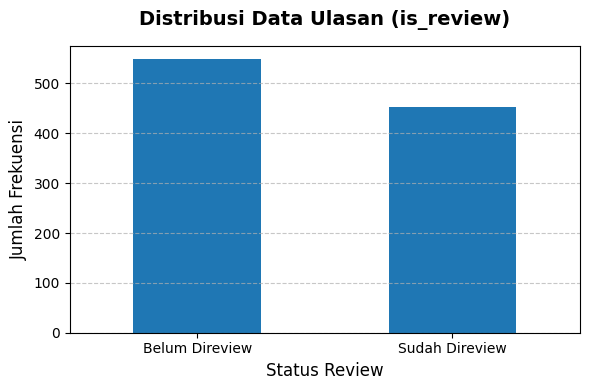

In [544]:
# 1. Hitung distribusi datanya terlebih dahulu
# Ini akan menghasilkan data text/kategori beserta jumlah frekuensinya
review_counts = df['is_review'].value_counts()

# 2. Membuat plot/grafik
plt.figure(figsize=(6, 4)) # Menentukan ukuran canvas grafik

# Membuat bar chart dengan warna kustom (opsional)
review_counts.plot(kind='bar')

# 3. Kustomisasi tampilan agar informatif dan rapi
plt.title('Distribusi Data Ulasan (is_review)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Review', fontsize=12)
plt.ylabel('Jumlah Frekuensi', fontsize=12)

# Mengatur label sumbu X agar tidak miring (rotation=0) dan lebih mudah dibaca
# Sesuaikan label di bawah ini dengan isi data asli Anda (misal: 0 dan 1 atau True dan False)
plt.xticks(ticks=range(len(review_counts)), labels=['Belum Direview', 'Sudah Direview'], rotation=0)

# Menambahkan garis bantu horizontal (grid) agar nilainya lebih mudah dibaca secara visual
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mengatur layout agar teks tidak terpotong
plt.tight_layout()

# 4. Tampilkan grafik ke layar
plt.show()

**Temuan:**

dalam tahap ini, melakukan exploration terhadap column 'is_review', terdapat 2 kategori product:
- belum review(+500)
- sudah review(+400)

dalam distribusi column 'is_review' telihat perbedaan jumlah product terhadap 2 kategori tersebut. lebih dari sebagian product belum direview,  jika chart tersbebut sebagai aktifitas jual beli  ini menandakan kurangnya minat konsumen terhadap sebagian product. jika ini dibiarkan akan menjadi bom waktu dikemudian hari terkhusus pada gudang penyimpanan product.  

### Top 10 product berdasarkan review_count

In [545]:
is_review = df[df['is_review']==1]
top_product = is_review.sort_values(by= 'review_count', ascending=False).head(10)
top_product.reset_index(drop=True,inplace=True)
top_product.index = top_product.index+1
display(top_product)


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
1,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
2,dbe68f3f-99a8-4ef2-a103-908a6fca244d,Wilson Fitness Equipment Pro,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,49.13,3.9,37,4,2024-10-31,1
3,eaaf2b74-b09a-4bf5-b0b2-09021044cab8,Instant Pot Microfiber Kitchenware,Transform your home with the Instant Pot Micro...,Home & Kitchen,Kitchenware,Instant Pot,94.87,4.2,28,2,2025-06-20,1
4,c1ab2206-9b50-4aaa-9446-f322d0976ea6,The Data Structures: A Comprehensive Guide,Discover the story behind The Data Structures:...,Books,Non-Fiction,Simon & Schuster,19.97,3.9,28,5000,2023-03-03,1
5,d3701c21-709a-4090-bab2-020261ce8a92,Cuisinart Smart Appliance,The Cuisinart Smart Appliance brings both styl...,Home & Kitchen,Appliances,Cuisinart,44.48,4.2,27,5,2023-08-21,1
6,25a6c99c-d63c-4697-91ef-744b7879d605,Post-it Premium Stationery Set,Stay organized and productive with the Post-it...,Office Products,Stationery,Post-it,45.91,4.1,26,1,2025-04-25,1
7,5d07bcd4-3670-4a0d-91f6-e36d7d335597,Adidas Sterling Silver Jewelry,Designed for those who refuse to compromise on...,Clothing & Accessories,Jewelry,Adidas,27.22,3.9,23,35,2024-12-27,1
8,88f38eae-9124-4557-a285-248fc1cad30c,Nestle Pantry Staple Multipack,Savor the rich flavors of the Nestle Pantry St...,Grocery & Gourmet,Pantry Staples,Nestle,7.74,4.1,22,8,2023-04-09,1
9,c2e39751-db17-424f-8d71-61ec7ecad424,Neutrogena Bath & Body Lotion,Nourish and pamper yourself with the Neutrogen...,Beauty & Personal Care,Bath & Body,Neutrogena,33.80,4.3,22,1,2024-08-29,1
10,58fd8edb-60ef-4856-bf1f-644ffc133d12,Wilson Book19 Fitness Equipment,Engineered for peak performance in any conditi...,Sports & Outdoors,Fitness Equipment,Wilson,107.09,4.3,21,55,2023-11-22,1


**Temuan:**

dalam 10 top product bedasarkan review_count terdapat macam-macam kondisi product seperti:
- krisis stock product
- anomaly stock product
- ideal stock product

 7/10 product memiliki krisis product seperti stock_quantity kurang dari 10 ini perlu di-intercept seperti restock darurat dan alihkan/rekomendasikan ke-brand lain jika permintaan melebihi stock yang ada. dan juga anomaly stock product hingga 5000 stock product, guna tidak terjadinya bom waktu pada gudang, treatment untuk product misal paket gratis untuk pembelian laptop atau barang relevan dengan tema buku. 



### Top 1 product berdasarkan review_count

In [546]:
accessories = is_review[is_review['subcategory']=='Accessories']
accessories.loc[df['product_description'].str.find('Accessorie Stand') != -1]


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1


**Temuan:**

product dengan naama accsessoie stand dengan brand apple menjadi top 1 product yang ter-indikasi kekurangan stock jika restock darurat tidak dapat dilaksanakan dengan baik maka memberi rekomendasi product serupa merupakan cara terbaik untuk sementara. productnya seperti dataframe diatas.


### Kenapa bisa top 1 product 

In [547]:
accessorie_stand = df.loc[df['product_description'].str.find('Accessorie Stand') != -1].copy()
print(f'jumlah product dengan nama Accessorie Stand : {len(accessorie_stand)}')
accessorie_stand

jumlah product dengan nama Accessorie Stand : 5


,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1
512,9bbf3ec0-bb7a-45a8-8500-1b2c03596f4d,Microsoft Accessorie Stand,"Engineered for excellence, the Microsoft Acces...",Electronics,Accessories,Microsoft,55.41,0.0,0,1,2023-01-19,0
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1
874,ddea521a-f6e7-4379-9a0f-841f828b1473,Samsung Accessorie Stand,The Samsung Accessorie Stand delivers exceptio...,Electronics,Accessories,Samsung,335.15,0.0,0,1,2024-05-29,0
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1


In [548]:
accessorie_stand['description_length'] = accessorie_stand['product_description'].astype(str).str.len()
tanggal_target = pd.to_datetime('2026-05-27')
accessorie_stand['product_age_days'] = (tanggal_target - accessorie_stand['date_added']).dt.days
# Membuat kategori berdasarkan jumlah hari
bins = [-1, 90, 180, 365, float('inf')]
labels = ['0-3 Bulan', '3-6 Bulan', '6-12 Bulan', 'Lebih dari 1 Tahun']
accessorie_stand['age_category'] = pd.cut(accessorie_stand['product_age_days'], bins=bins, labels=labels)
display(accessorie_stand.sort_values(by= 'review_count',ascending=False))
accessorie_stand.describe().round(2)



,product_id,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added,is_review,description_length,product_age_days,age_category
34,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,Apple Accessorie Stand,Experience cutting-edge technology with the Ap...,Electronics,Accessories,Apple,70.02,4.1,49,1,2023-03-29,1,658,1155,Lebih dari 1 Tahun
957,4b9c83ae-69fe-4826-ac62-bae53913ea33,Apple Accessorie Stand,"Engineered for excellence, the Apple Accessori...",Electronics,Accessories,Apple,286.89,3.8,5,8,2023-11-03,1,664,936,Lebih dari 1 Tahun
718,1e7c79d1-0a00-4d37-b3e1-2f6262900884,Samsung Accessorie Stand,Upgrade your setup with the powerful Samsung A...,Electronics,Accessories,Samsung,90.86,3.0,1,2,2025-09-26,1,720,243,6-12 Bulan
512,9bbf3ec0-bb7a-45a8-8500-1b2c03596f4d,Microsoft Accessorie Stand,"Engineered for excellence, the Microsoft Acces...",Electronics,Accessories,Microsoft,55.41,0.0,0,1,2023-01-19,0,560,1224,Lebih dari 1 Tahun
874,ddea521a-f6e7-4379-9a0f-841f828b1473,Samsung Accessorie Stand,The Samsung Accessorie Stand delivers exceptio...,Electronics,Accessories,Samsung,335.15,0.0,0,1,2024-05-29,0,502,728,Lebih dari 1 Tahun


,price,rating_avg,review_count,stock_quantity,date_added,is_review,description_length,product_age_days
count,5.00,5.00,5.00,5.00,5,5.00,5.00,5.00
mean,167.67,2.18,11.00,2.60,2024-01-20 19:12:00,0.60,620.80,857.20
min,55.41,0.00,0.00,1.00,2023-01-19 00:00:00,0.00,502.00,243.00
25%,70.02,0.00,0.00,1.00,2023-03-29 00:00:00,0.00,560.00,728.00
50%,90.86,3.00,1.00,1.00,2023-11-03 00:00:00,1.00,658.00,936.00
75%,286.89,3.80,5.00,2.00,2024-05-29 00:00:00,1.00,664.00,1155.00
max,335.15,4.10,49.00,8.00,2025-09-26 00:00:00,1.00,720.00,1224.00
std,132.57,2.03,21.34,3.05,NaN,0.55,87.89,394.77


**Temuan:**

kenapa product accessori stand dengan product_id '6e9b539a-77ad-4307-acb5-f558f8b5cc6f' menjadi top 1 product dikarnakan:
- dari sebaran harga, sebagian pembeli product accessori stand lebih menyukai harga sekitar 90.86
- sebagian pembeli menyukai deskripsi lengkap dengan panjang sekitar 658 per huruf
- sebagian pembeli lebih menyukai product dari band apple dan productnya telah direview dikarenakan memiliki rating


### Kesimpulan

Ketidakseimbangan inventaris gudang yang ekstrem—ditunjukkan oleh ancaman *stockout* pada **70% produk populer** (stok `< 10` unit, seperti *accessory stand* Apple) dan akumulasi *deadstock* hingga **5.000 unit** pada **>50% produk sepi peminat**—mengancam efisiensi kapasitas gudang dan potensi pendapatan bisnis. 

Masalah ini terjadi karena belum adanya pemetaan berbasis data yang menghubungkan kriteria preferensi pembeli (sensitivitas harga `~90.86`, kelengkapan deskripsi `~658` karakter, dan *rating*) dengan status perputaran stok. 

Oleh karena itu, diperlukan pemodelan ***clustering*** untuk mengelompokkan produk berdasarkan tingkat kesehatan stok (**Krisis**, **Ideal**, dan **Anomali**) sebagai dasar pengambilan keputusan manajemen inventaris dan strategi operasional gudang yang presisi.

## Feature Engineering

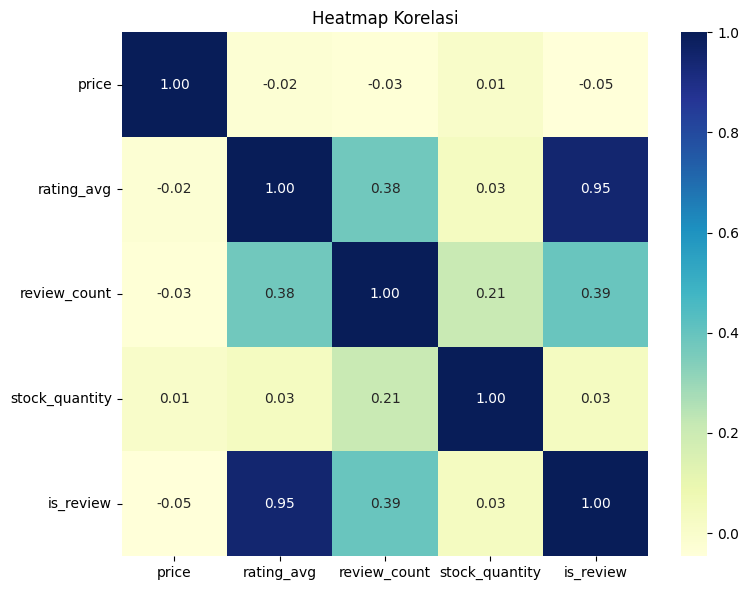

In [549]:
# 1. Ambil data numerik & hitung korelasi
data = df.select_dtypes(exclude='object').drop(columns=['date_added'], errors='ignore')
correlation = data.corr()

# 2. Buat heatmap standar
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

**Temuan:**
sebelum seleksi features perlu dilakukan menghitung korelasi antar variable dengan visualiasi heatmap dataframe. pada gambar tersebut variable price tidak memiliki korelasi yang signifikan antar variable. yang artinya harga tidak menentukan fequensi pembelian(review_count) maka:
- review_count 
- rating_avg
- stock quantity

variable tersebut features dan memiliki korelasi lebih signifikan dari variable price

### Define X

In [550]:
# Membuat fitur numerik tambahan yang relevan
df['description_length'] = df['product_description'].astype(str).str.len()
tanggal_target = pd.to_datetime('2026-05-27')
df['product_age_days'] = (tanggal_target - df['date_added']).dt.days



In [551]:

# seleksi features
df_is_review = df[df['is_review']==1]
features = ['rating_avg','review_count','stock_quantity']

# define features
X = df_is_review[features]

# difine kolom numerik
num_cols = list(X.select_dtypes(exclude='object').columns)
print(f"Numerik kolom  : {num_cols}")

Numerik kolom  : ['rating_avg', 'review_count', 'stock_quantity']


### Handling outlier

In [552]:
#check distribution form skewness
listItem= []

for col in num_cols:
  listItem.append([col, round(X[col].skew(),1), np.where(
    (round(X[col].skew(),1) <= 0.5) & (round(X[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])

skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness


,nama kolom,nilai skewness,distribution
0,rating_avg,-1.2,skewed
1,review_count,5.0,skewed
2,stock_quantity,19.2,skewed


In [553]:
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range(0, len(skewness)):
    col = skewness["nama kolom"][row]

    # 1. Tentukan Boundary Dasar
    # Khusus kolom dengan extreme skewness (review_count & stock_quantity), gunakan Persentil 95%
    if col in ['stock_quantity', 'review_count']:
        lower_boundary = X[col].min()  # Nilai terendah asli (misal: 1)
        upper_boundary = X[col].quantile(0.95)  # Ambil batas 95% data terbanyak

    elif skewness["distribution"][row] == "skewed":
        IQR = X[col].quantile(0.75) - X[col].quantile(0.25)
        lower_boundary = X[col].quantile(0.25) - (IQR * 3)
        upper_boundary = X[col].quantile(0.75) + (IQR * 3)
    else:
        lower_boundary = X[col].mean() - 3 * X[col].std()
        upper_boundary = X[col].mean() + 3 * X[col].std()

    # -------------------------------------------------------------
    # 2. LOGIKA BISNIS (Domain Rules & Safety Net)
    # -------------------------------------------------------------
    # Khusus rating_avg, batas atas mutlak adalah 5.0
    if col == "rating_avg":
        lower_boundary = max(lower_boundary, 0.0)
        upper_boundary = min(upper_boundary, 5.0)

    # Memastikan batas bawah angka kuantitatif tidak minus
    if lower_boundary < 0:
        lower_boundary = 0.0

    # 3. Hitung statistik outlier
    totout = (len(X[X[col] > upper_boundary]) / len(X) * 100) + (
        len(X[X[col] < lower_boundary]) / len(X) * 100
    )

    column.append(col)
    lower_bound.append(lower_boundary)
    upper_bound.append(upper_boundary)
    percent_total_outlier.append(totout)

    # 4. Eksekusi Capping
    X[col] = np.clip(X[col], a_min=lower_boundary, a_max=upper_boundary)

# Buat DataFrame ringkasan
outliers_X = pd.DataFrame(
    {
        "column": column,
        "upper_boundary": [round(ub, 2) for ub in upper_bound],
        "lower_boundary": [round(lb, 2) for lb in lower_bound],
        "percentage_total_outlier": [
            round(p, 2) for p in percent_total_outlier
        ],
    }
)

outliers_X

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,rating_avg,5.00,0.0,0.00
1,review_count,10.45,1.0,5.09
2,stock_quantity,44.40,1.0,5.09


**Temuan:**

dataframe diatas merupakan hasil dari tahap cheking outlier menggunakan metode iqr, dari dataframe diatas:
- review_count
- stock_quantity

varible tersebut memiliki persentase outlier melebihi dari 5% atau 0,05 dengan nilai itu harus di-intercep seperti trim atau capping, pada kali ini saya akan melakukan cappping dengan membero batas lowwer boundery iqr dengan angka minimum dan rating_avg menerapkan 0 dan 5 untuk lower dan upper dari rating_avg guna memaksimalkan data dan tahap selanjutnya scaling, pada tahap tebebut akan mnegununakan StandarScaling agar tahan dari outlier

### Scaling

In [554]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

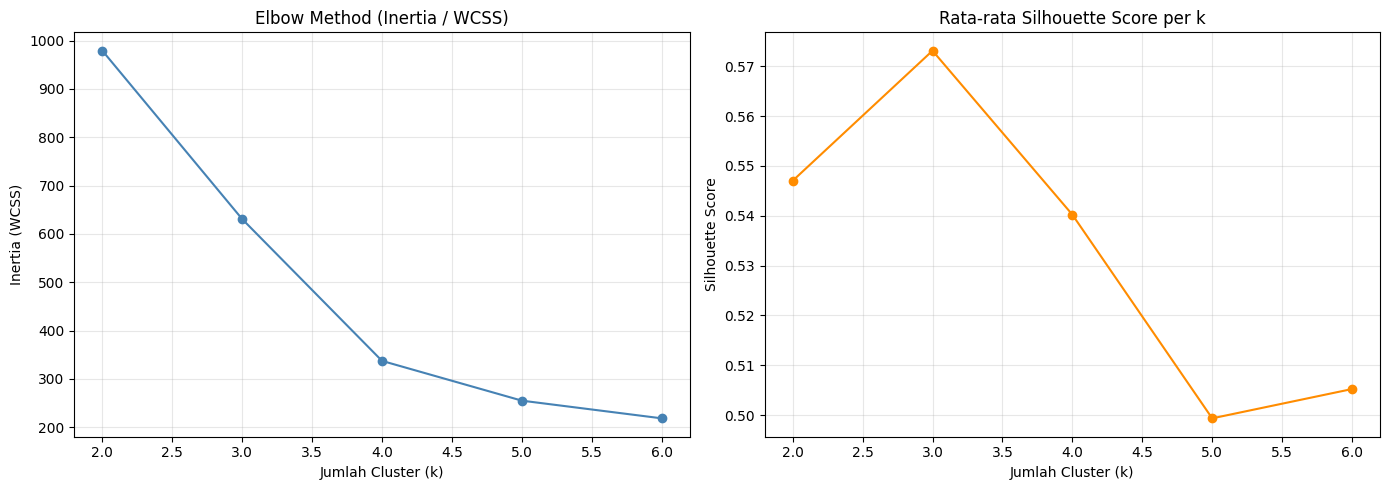

In [555]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

k_range = range(2, 7)
inertia_list = []
silhouette_avg_list = []

# ------------------------------------------------------------------
# 1. ELBOW METHOD (Inertia / WCSS)
# ------------------------------------------------------------------
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_list.append(kmeans.inertia_)
    silhouette_avg_list.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertia_list, marker='o', color='steelblue')
axes[0].set_title('Elbow Method (Inertia / WCSS)')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=0.3)

# Silhouette score line plot (trend, bukan cuma print angka)
axes[1].plot(list(k_range), silhouette_avg_list, marker='o', color='darkorange')
axes[1].set_title('Rata-rata Silhouette Score per k')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



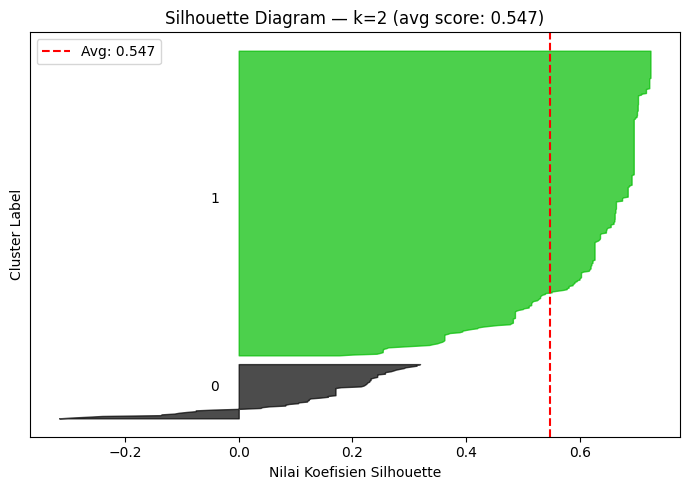

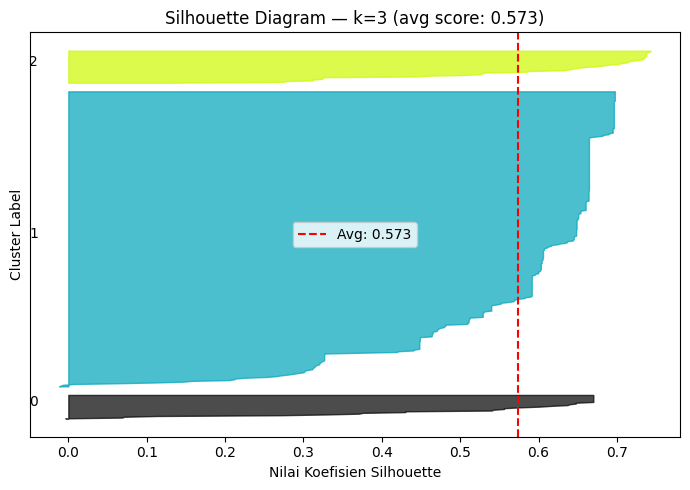

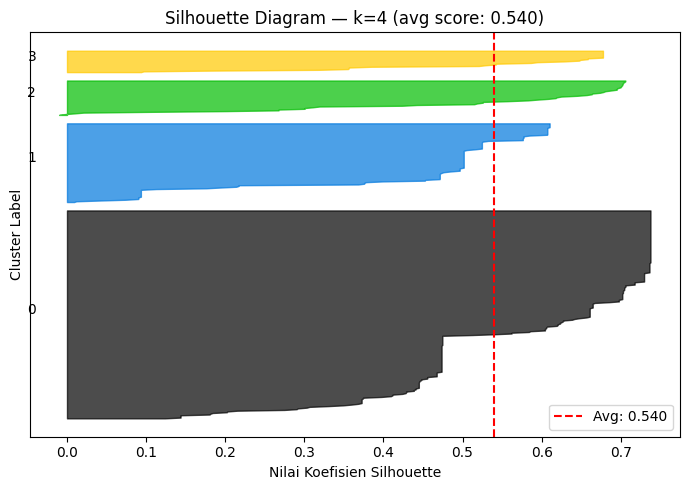

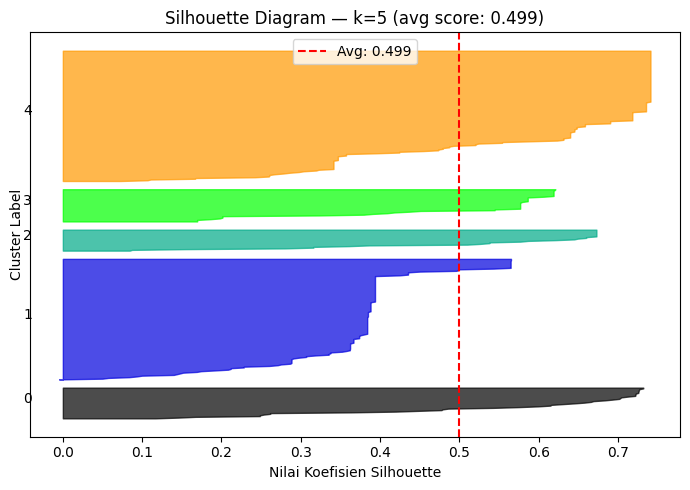

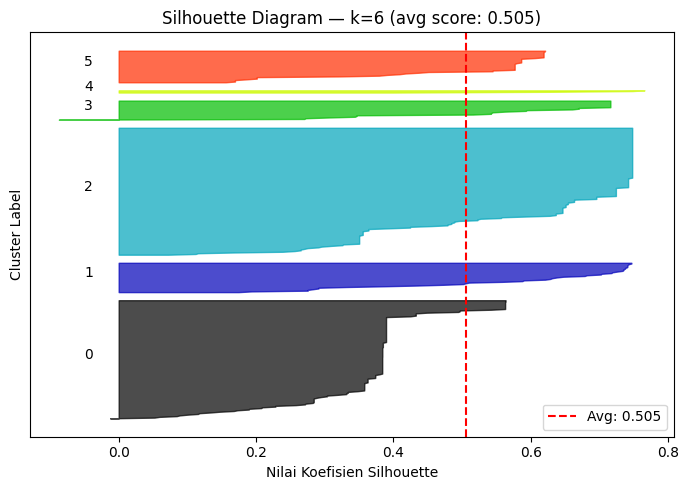

In [556]:
# ------------------------------------------------------------------
# 2. SILHOUETTE DIAGRAM per k (detail per-sample, bukan cuma rata-rata)
# ------------------------------------------------------------------
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    fig, ax = plt.subplots(figsize=(7, 5))
    y_lower = 10

    for i in range(k):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, ith_cluster_values,
            facecolor=color, edgecolor=color, alpha=0.7
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"Silhouette Diagram — k={k} (avg score: {silhouette_avg:.3f})")
    ax.set_xlabel("Nilai Koefisien Silhouette")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg: {silhouette_avg:.3f}")
    ax.legend()
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

In [557]:
# Menghitung Silhouette Score untuk k=2 sampai k=6
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} | Silhouette Score: {score:.3f}")

k=2 | Silhouette Score: 0.547
k=3 | Silhouette Score: 0.573
k=4 | Silhouette Score: 0.540
k=5 | Silhouette Score: 0.499
k=6 | Silhouette Score: 0.505


In [558]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_is_review['cluster'] = kmeans.fit_predict(X_scaled)

In [559]:
df_is_review['cluster'].value_counts()

cluster
0    273
1    104
2     46
3     29
Name: count, dtype: int64

## EDA After Cluster

In [560]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_column_by_cluster(df, cluster_col='cluster', df_column='price', bins=20):
    """
    Membuat subplot distribusi column untuk setiap cluster.
    
    Parameters:
    - df: pandas DataFrame
    - cluster_col: nama kolom cluster (default: 'cluster')
    - df_column: nama kolom harga (default: 'price')
    - bins: jumlah batang interval histogram
    """
    clusters = sorted(df[cluster_col].unique())
    n_clusters = len(clusters)
    
    # Menentukan grid subplot (maksimal 3 kolom per baris)
    ncols = min(n_clusters, 3)
    nrows = math.ceil(n_clusters / ncols)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.flatten()
    
    for i, cluster_id in enumerate(clusters):
        subset = df[df[cluster_col] == cluster_id]
        ax = axes[i]
        
        # Plot Histogram & Kernel Density Estimation (KDE)
        sns.histplot(subset[df_column], kde=True, ax=ax, color=f'C{i}', bins=bins)
        
        # Indikator Mean dan Median
        mean_val = subset[df_column].mean()
        median_val = subset[df_column].median()
        
        ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.1f}')
        ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:,.1f}')
        
        # Judul & Label
        ax.set_title(f'Cluster {cluster_id} (n={len(subset)})', fontsize=12, fontweight='bold')
        ax.set_xlabel(df_column.capitalize())
        ax.set_ylabel('Frekuensi')
        ax.legend()
        
    # Menghapus subplot kosong jika jumlah cluster tidak memenuhi grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

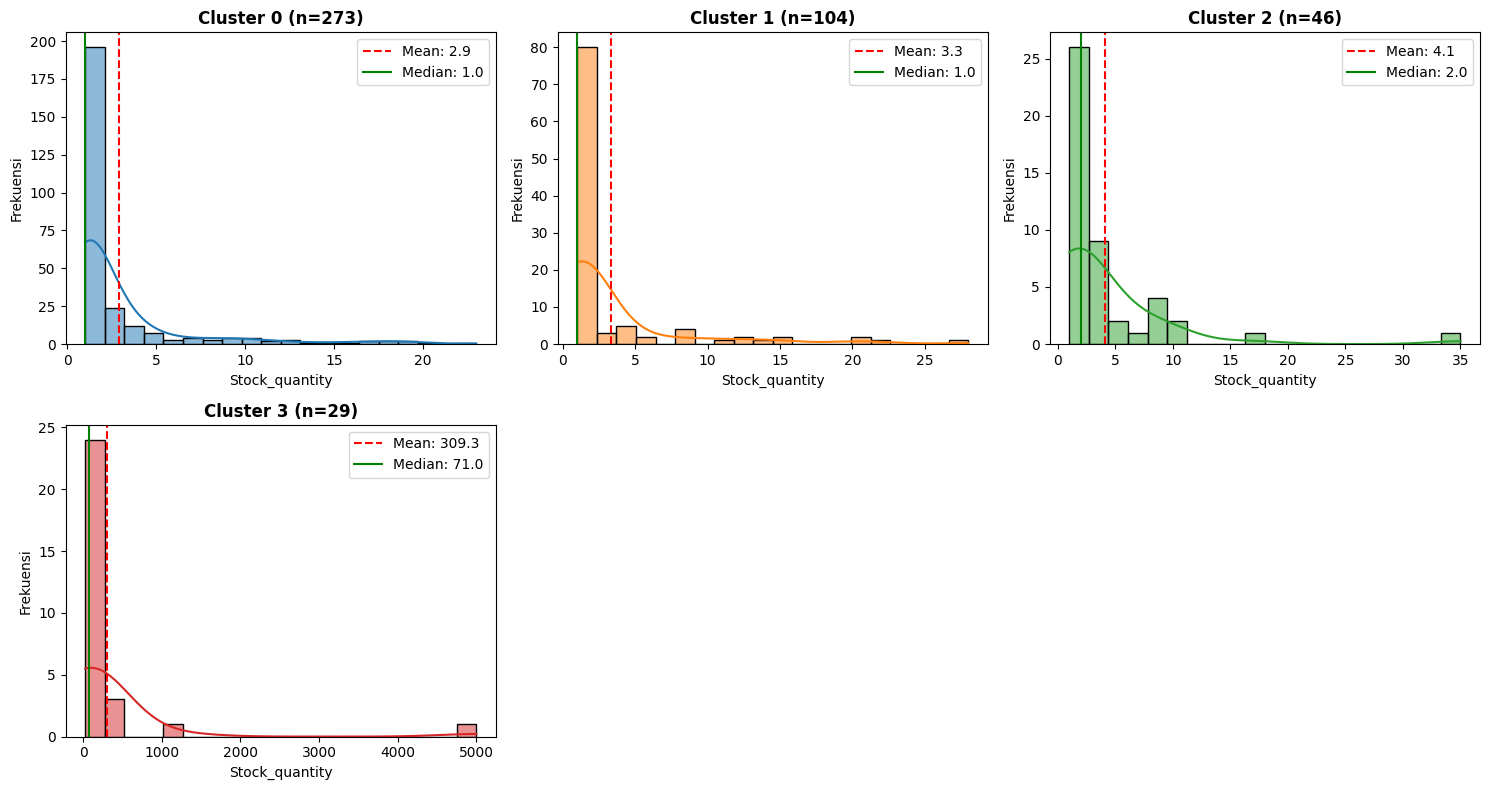

In [561]:
plot_column_by_cluster(df_is_review, cluster_col='cluster', df_column='stock_quantity')


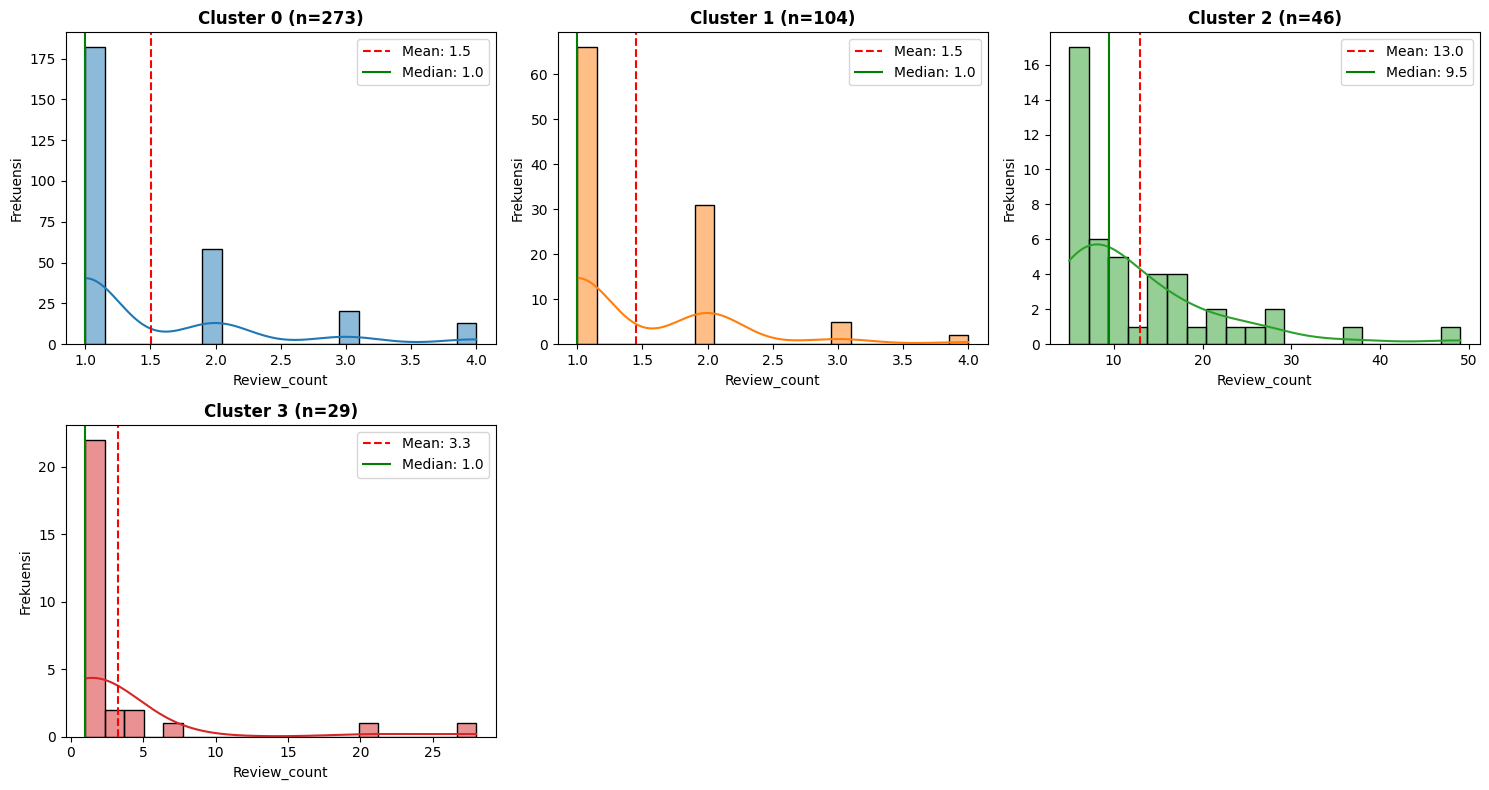

In [562]:
plot_column_by_cluster(df_is_review, cluster_col='cluster', df_column='review_count')


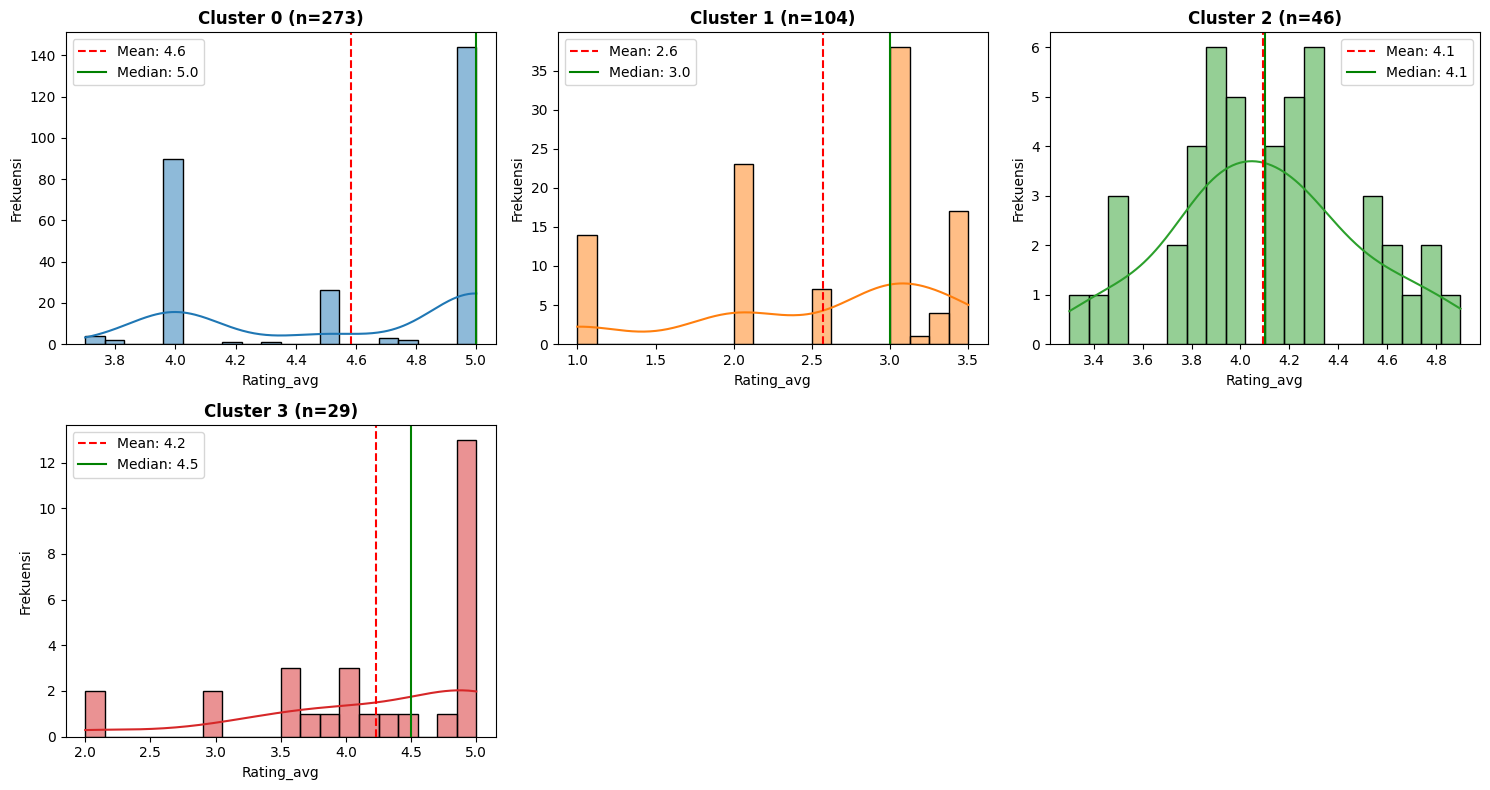

In [563]:
plot_column_by_cluster(df_is_review, cluster_col='cluster', df_column='rating_avg')


In [564]:
# 1. Tentukan variabel yang dipost-analysis (variabel yang TIDAK masuk ke K-Means)
post_vars = ['price', 'product_age_days', 'description_length']

# 2. Hitung rata-rata tiap variabel pendukung per cluster
post_analysis_df = df_is_review.groupby('cluster')[post_vars].mean().round(2)

# 3. Tampilkan profil lengkap (gabungan core features + post-analysis features)
core_vars = ['rating_avg', 'review_count', 'stock_quantity']
full_profile = df_is_review.groupby('cluster')[core_vars + post_vars].mean().round(2)

print("--- PROFIL LENGKAP CLUSTER (DENGAN POST-ANALYSIS) ---")
full_profile

--- PROFIL LENGKAP CLUSTER (DENGAN POST-ANALYSIS) ---


,rating_avg,review_count,stock_quantity,price,product_age_days,description_length
cluster,,,,,,
0,4.58,1.50,2.90,73.09,628.78,501.25
1,2.57,1.45,3.30,53.70,605.69,517.33
2,4.09,12.98,4.07,54.07,693.78,487.74
3,4.23,3.28,309.28,53.08,715.59,514.10


# Dokumentasi Hasil Analisis Klasterisasi Produk

---

##  Ringkasan Eksekutif

Analisis klasterisasi terbaru mengelompokkan data ke dalam **4 cluster utama**. Pengelompokan ini menunjukkan pemisahan yang sangat kontras berdasarkan indikator performa kepuasan pelanggan (**`rating_avg`**), tingkat popularitas/interaksi pasar (**`review_count`**), serta kuantitas pasokan gudang (**`stock_quantity`**).

---

##  Profil dan Karakteristik Cluster

### **Cluster 0: Premium & High Rating (Kualitas Terbaik / Stok Menipis)**
* **Ukuran Sampel ($n$):** 273 produk *(Klaster Terbesar)*
* **Rata-rata Rating (`rating_avg`):** **4,58** *(Paling Tinggi / Sangat Memuaskan)*
* **Rata-rata Harga (`price`):** **73,09** *(Paling Mahal)*
* **Rata-rata Stok (`stock_quantity`):** **2,90 unit** *(Sangat Menipis)*
* **Rata-rata Ulasan (`review_count`):** **1,50 ulasan**
* **Usia Produk (`product_age_days`):** **628,78 hari**

> **Kesimpulan:** Segmen ini mewakili **produk kelas premium berharga tinggi dengan tingkat kepuasan pelanggan tertinggi (rating 4.58)**. Meskipun produk ini dipercaya oleh pembeli, ketersediaan stoknya tergolong sangat terbatas (~2.9 unit).

---

### **Cluster 1: Low Rating / Underperforming Product (Perlu Evaluasi Kualitas)**
* **Ukuran Sampel ($n$):** 104 produk
* **Rata-rata Rating (`rating_avg`):** **2,57** *(Paling Rendah / Kurang Memuaskan)*
* **Rata-rata Stok (`stock_quantity`):** **3,30 unit** *(Stok Sedikit)*
* **Rata-rata Ulasan (`review_count`):** **1,45 ulasan** *(Paling Sedikit)*
* **Rata-rata Harga (`price`):** **53,70**
* **Usia Produk (`product_age_days`):** **605,69 hari** *(Paling Muda)*

> **Kesimpulan:** Segmen ini mengidentifikasi **produk dengan kinerja paling buruk (*underperforming*)** karena memiliki nilai *rating* terendah (2.57) serta interaksi ulasan yang sangat minim.

---

### **Cluster 2: Most Popular / High Demand Product (Paling Laris & Banyak Ulasan)**
* **Ukuran Sampel ($n$):** 46 produk
* **Rata-rata Ulasan (`review_count`):** **12,98 ulasan** *(Sangat Tinggi / Paling Populer)*
* **Rata-rata Rating (`rating_avg`):** **4,09** *(Sangat Baik)*
* **Rata-rata Stok (`stock_quantity`):** **4,07 unit** *(Stok Sedikit)*
* **Rata-rata Harga (`price`):** **54,07**
* **Usia Produk (`product_age_days`):** **693,78 hari**

> **Kesimpulan:** Segmen ini merupakan **produk paling populer dan *fast-moving*** dengan akumulasi ulasan tertinggi (~13 ulasan per produk). Meskipun penjualan dan interaksi pembeli tinggi, pasokan stok di gudang tergolong sangat sedikit (~4 unit).

---

### **Cluster 3: Bulk Stock / Mass Storage Product (Stok Melimpah)**
* **Ukuran Sampel ($n$):** 29 produk
* **Rata-rata Stok (`stock_quantity`):** **309,28 unit** *(Sangat Melimpah)*
* **Rata-rata Rating (`rating_avg`):** **4,23** *(Tinggi)*
* **Rata-rata Ulasan (`review_count`):** **3,28 ulasan**
* **Rata-rata Harga (`price`):** **53,08** *(Paling Terjangkau)*
* **Usia Produk (`product_age_days`):** **715,59 hari** *(Paling Senior)*

> **Kesimpulan:** Segmen ini adalah **produk senior/lama dengan ketersediaan stok paling aman dan melimpah** (~309 unit). Memiliki kombinasi harga terjangkau dan kepuasan pelanggan yang sangat baik (rating 4.23).

---

##  Tabel Komparatif Profil Cluster

| Parameter / Fitur | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
| :--- | :---: | :---: | :---: | :---: |
| **Label Operasional** | **Premium / High Rating** | **Low Rating / Underperforming** | **High Demand / Most Popular** | **Bulk Stock / Mass Storage** |
| **Ukuran Klaster ($n$)** | **273** | **104** | **46** | **29** |
| **Rata-rata Rating (`rating_avg`)** | **4.58**  | **2.57**  | 4.09 | 4.23 |
| **Jumlah Ulasan (`review_count`)** | 1.50 | 1.45 | **12.98**  | 3.28 |
| **Jumlah Stok (`stock_quantity`)** | 2.90 | 3.30 | 4.07 | **309.28**  |
| **Harga (`price`)** | **73.09**  | 53.70 | 54.07 | 53.08 |
| **Usia Produk (Hari)** | 628.78 | 605.69 | 693.78 | **715.59** |

---

##  Matriks Rekomendasi Strategis
1. **Cluster 2 (High Demand) & Cluster 0 (Premium):** **PRIORITAS RESTOCK**. 
   * **Cluster 2** adalah produk yang paling diminati pasar (*review_count* 12.98), sedangkan 
   * **Cluster 0** adalah produk *high-margin* ber-rating tertinggi (4.58). Keduanya sama-sama memiliki stok yang sangat kritis (< 5 unit) sehingga perlu pemesanan ulang (*restock*) secepatnya.
2. **Cluster 1 (Underperforming):** **QUALITY CONTROL & AUDIT**.
   * Diperlukan evaluasi mendalam terkait kelayakan produk, deskripsi, atau vendor, mengingat *rating*-nya sangat rendah (2.57) yang dapat merusak citra toko.
3. **Cluster 3 (Bulk Stock):** **MARKETING CAMPAIGN**.
   * Karena stok melimpah (309 unit) dan *rating* produk sangat bagus (4.23), buatlah program diskon/promosi bundel untuk mempercepat perputaran inventaris (*inventory turnover*).